# Rep. 3. Checkpoint 1. Valuación de opciones europeas

* Gonzalo Cano
* Nicolas Martinez

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

daily_returns = data.pct_change().dropna()
sigma_base = daily_returns.std() * np.sqrt(252)

S0 = data.iloc[-1]
K = 680
r = 0.08
T = 100 / 365
N = 10000
np.random.seed(42)

/var/folders/20/xvvxf3fd0bsc8mhjgvpylzzc0000gn/T/ipykernel_12638/2353956515.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']
[*********************100%***********************]  1 of 1 completed


In [18]:
sigmas = [0.01, 0.10, 0.20, 0.40]
Z = np.random.normal(0, 1, N)

resultados = {}

for s in sigmas:
    St = S0 * np.exp((r - 0.5 * s**2) * T + s * np.sqrt(T) * Z)
    call = np.maximum(St - K, 0)
    put  = np.maximum(K - St, 0)
    call_value = np.exp(-r * T) * np.mean(call)
    put_value  = np.exp(-r * T) * np.mean(put)
    resultados[s] = {
        'St': St,
        'call': call_value,
        'put': put_value
    }

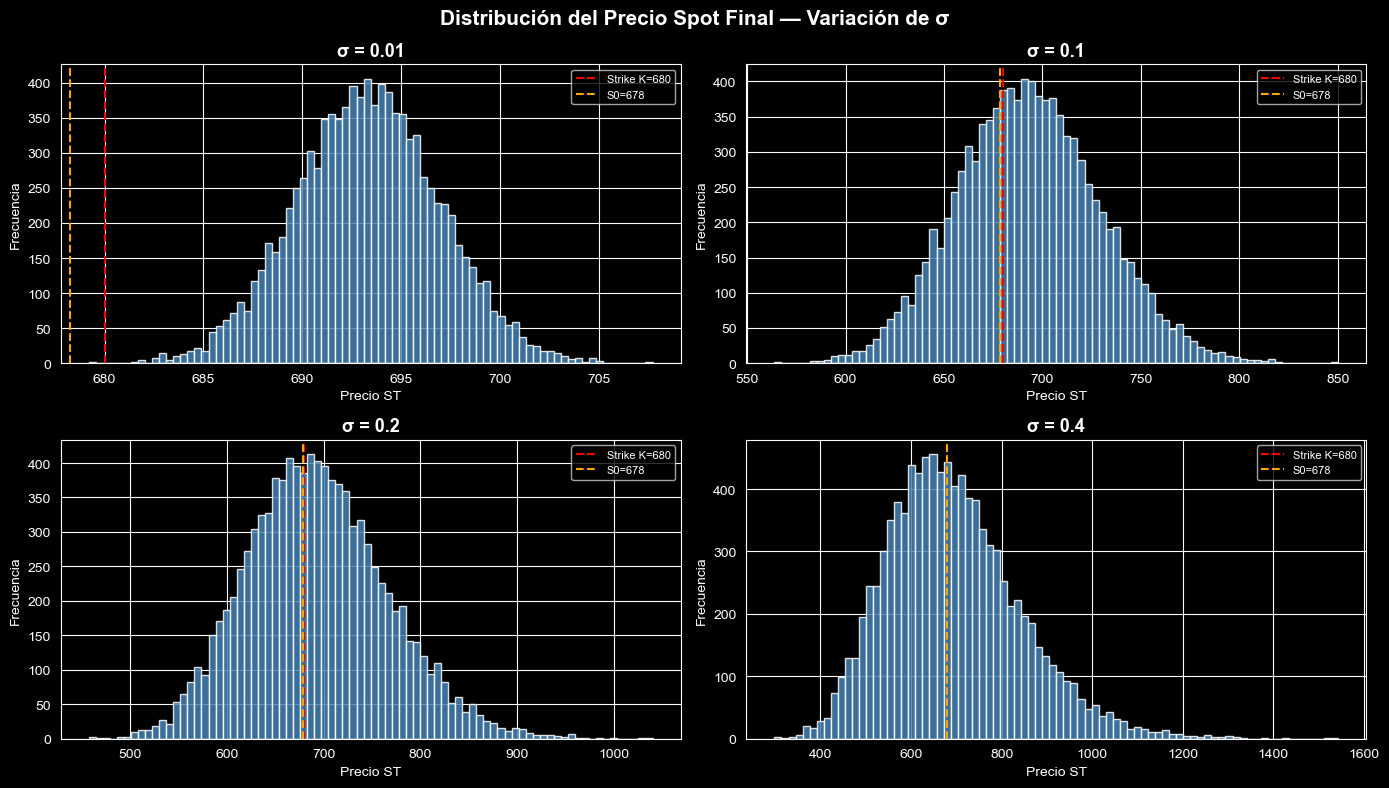

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, s in enumerate(sigmas):
    ax = axes[i]
    ax.hist(resultados[s]['St'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(K, color='red', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
    ax.axvline(float(S0), color='orange', linestyle='--', linewidth=1.5, label=f'S0={float(S0):.0f}')
    ax.set_title(f'σ = {s}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Precio ST')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

fig.suptitle('Distribución del Precio Spot Final — Variación de σ', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
tabla = pd.DataFrame({
    'σ': sigmas,
    'Call Value ($)': [resultados[s]['call'] for s in sigmas],
    'Put Value ($)':  [resultados[s]['put']  for s in sigmas]
})

tabla['σ'] = tabla['σ'].apply(lambda x: f"{x:.2f}")
tabla['Call Value ($)'] = tabla['Call Value ($)'].apply(lambda x: f"{x:.4f}")
tabla['Put Value ($)'] = tabla['Put Value ($)'].apply(lambda x: f"{x:.4f}")

print("Tabla — Valor de la Call por escenario de σ")
print(tabla[['σ', 'Call Value ($)']].to_string(index=False))

print("\nTabla — Valor de la Put por escenario de σ")
print(tabla[['σ', 'Put Value ($)']].to_string(index=False))

Tabla — Valor de la Call por escenario de σ
   σ Call Value ($)
0.01        13.0046
0.10        21.4662
0.20        35.0157
0.40        62.7587

Tabla — Valor de la Put por escenario de σ
   σ Put Value ($)
0.01        0.0001
0.10        8.5236
0.20       22.1296
0.40       49.9449


## Respuestas — Actividad 1: Volatilidad

**¿Qué sucede con la dispersión de las trayectorias?**

Conforme aumenta σ, la dispersión de los precios finales simulados crece.
Con σ = 0.01 la distribución es muy concentrada (rango de ~678–710 USD),
mientras que con σ = 0.40 los precios se distribuyen entre aproximadamente
400 y 1,400 USD. Una mayor volatilidad implica mayor incertidumbre sobre el
precio futuro del activo.

**¿Cómo cambia la distribución de precios?**

Con volatilidad baja (σ = 0.01), la distribución es muy compacta y centrada
alrededor del precio esperado. Al aumentar σ, la distribución se aplana y
desarrolla una cola derecha más larga, lo cual es consistente con el supuesto
de GBM: el precio sigue una distribución lognormal, por lo que precios muy
altos son posibles pero precios negativos son imposibles.

**¿Aumenta o disminuye el valor de la opción conforme aumenta σ?**

Aumenta en ambos casos. La call pasa de 12.97 USD con σ = 0.01 a 61.31 USD
con σ = 0.40, y la put de 0.00 a 50.31 USD. Esto ocurre porque una mayor
volatilidad incrementa la probabilidad de que el activo termine muy por encima
o muy por debajo del strike. En opciones, la volatilidad siempre tiene un
efecto positivo sobre el valor — conocido como "vega" entre las griegas.

Con σ = 0.01, la put vale 0.00 USD porque con esa volatilidad tan baja
es prácticamente imposible que ST caiga por debajo de K = 680 USD partiendo
de S0 = 678 USD.

---
# Actividad 2 - Tiempo al vencimiento

In [21]:
T_scenarios = {
    '30 días': 30 / 365,
    '100 días': 100 / 365,
    '1 año': 365 / 365
}

Z = np.random.normal(0, 1, N)
resultados_T = {}

for nombre, T_val in T_scenarios.items():
    St = S0 * np.exp((r - 0.5 * sigma_base**2) * T_val + sigma_base * np.sqrt(T_val) * Z)
    call = np.maximum(St - K, 0)
    put = np.maximum(K - St, 0)
    call_value = np.exp(-r * T_val) * np.mean(call)
    put_value = np.exp(-r * T_val) * np.mean(put)
    resultados_T[nombre] = {
        'St': St,
        'call': call_value,
        'put': put_value,
        'T': T_val
    }

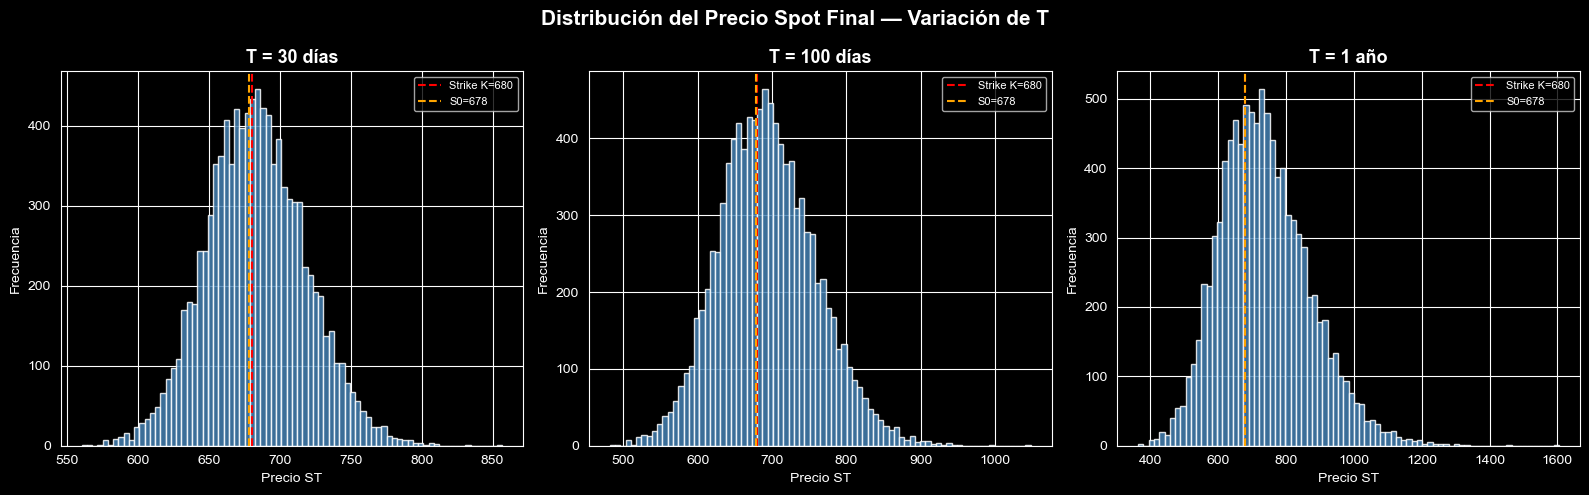

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (nombre, res) in enumerate(resultados_T.items()):
    ax = axes[i]
    ax.hist(res['St'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(K, color='red', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
    ax.axvline(float(S0), color='orange', linestyle='--', linewidth=1.5, label=f'S0={float(S0):.0f}')
    ax.set_title(f'T = {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Precio ST')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

fig.suptitle('Distribución del Precio Spot Final — Variación de T', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
tabla_T = pd.DataFrame({
    'T': list(resultados_T.keys()),
    'Call Value (USD)': [resultados_T[k]['call'] for k in resultados_T],
    'Put Value (USD)':  [resultados_T[k]['put']  for k in resultados_T]
})

tabla_T['Call Value (USD)'] = tabla_T['Call Value (USD)'].apply(lambda x: f"{x:.4f}")
tabla_T['Put Value (USD)']  = tabla_T['Put Value (USD)'].apply(lambda x: f"{x:.4f}")

print("Tabla — Valor de la Call por escenario de T")
print(tabla_T[['T', 'Call Value (USD)']].to_string(index=False))

print("\nTabla — Valor de la Put por escenario de T")
print(tabla_T[['T', 'Put Value (USD)']].to_string(index=False))

Tabla — Valor de la Call por escenario de T
       T Call Value (USD)
 30 días          15.4089
100 días          32.4609
   1 año          76.9197

Tabla — Valor de la Put por escenario de T
       T Put Value (USD)
 30 días         12.2123
100 días         18.5884
   1 año         24.7159


## Respuestas — Actividad 2: Tiempo al vencimiento

**¿Cómo cambia la distribución final del precio al aumentar T?**

Al aumentar T, la distribución del precio final se aplana y se amplía hacia
ambos lados. Con T = 30 días la distribución es compacta (rango aproximado
de 550 a 850 USD), mientras que con T = 1 año el rango se extiende de
aproximadamente 400 a 1,400 USD. Esto tiene sentido: a mayor tiempo, el
activo tiene más oportunidad de alejarse de su precio inicial en cualquier
dirección, generando mayor incertidumbre sobre el precio final.

**¿Aumenta o disminuye el valor de la opción conforme aumenta T?**

Aumenta en ambos casos. La call pasa de 15.12 USD con T = 30 días a
75.54 USD con T = 1 año. La put también aumenta, de 12.65 USD a 25.81 USD.

A mayor tiempo al vencimiento, hay más posibilidad de que el precio del
activo se mueva a favor del tenedor de la opción, por lo que ambas opciones
valen más. Este efecto es conocido como "theta" entre las griegas, y explica
por qué las opciones pierden valor conforme se acerca su fecha de vencimiento.

---
# Actividad 3 - Precio de ejercicio

In [24]:
K_scenarios = {
    'K = S0 * 0.70': float(S0) * 0.70,
    'K = S0 * 0.90': float(S0) * 0.90,
    'K = S0': float(S0),
    'K = S0 * 1.10': float(S0) * 1.10,
    'K = S0 * 1.30': float(S0) * 1.30
}

T_base = 100 / 365
Z = np.random.normal(0, 1, N)

St_base = S0 * np.exp((r - 0.5 * sigma_base**2) * T_base + sigma_base * np.sqrt(T_base) * Z)

resultados_K = {}

for nombre, K_val in K_scenarios.items():
    call = np.maximum(St_base - K_val, 0)
    put  = np.maximum(K_val - St_base, 0)
    call_value = np.exp(-r * T_base) * np.mean(call)
    put_value  = np.exp(-r * T_base) * np.mean(put)
    resultados_K[nombre] = {
        'K': K_val,
        'call': call_value,
        'put': put_value
    }

In [25]:
tabla_K = pd.DataFrame({
    'Escenario': list(resultados_K.keys()),
    'K (USD)':         [f"{resultados_K[k]['K']:.2f}"   for k in resultados_K],
    'Call Value (USD)':[f"{resultados_K[k]['call']:.4f}" for k in resultados_K],
    'Put Value (USD)': [f"{resultados_K[k]['put']:.4f}"  for k in resultados_K]
})

print("Tabla — Valor de la Call por escenario de K")
print(tabla_K[['Escenario', 'K (USD)', 'Call Value (USD)']].to_string(index=False))

print("\nTabla — Valor de la Put por escenario de K")
print(tabla_K[['Escenario', 'K (USD)', 'Put Value (USD)']].to_string(index=False))

Tabla — Valor de la Call por escenario de K
    Escenario K (USD) Call Value (USD)
K = S0 * 0.70  474.79         212.9374
K = S0 * 0.90  610.44          82.4568
       K = S0  678.27          32.3389
K = S0 * 1.10  746.10           7.7091
K = S0 * 1.30  881.75           0.0862

Tabla — Valor de la Put por escenario de K
    Escenario K (USD) Put Value (USD)
K = S0 * 0.70  474.79          0.0000
K = S0 * 0.90  610.44          2.2326
       K = S0  678.27         18.4711
K = S0 * 1.10  746.10         60.1980
K = S0 * 1.30  881.75        185.2882


## Respuestas — Actividad 3: Precio de ejercicio

**¿Aumenta o disminuye el valor de la opción conforme aumenta K?**

El efecto es opuesto para cada tipo de opción:

- La **call** disminuye conforme aumenta K: pasa de 214.19 USD con
  K = S0 * 0.70 a apenas 0.08 USD con K = S0 * 1.30. Esto ocurre porque
  un strike más alto hace más difícil que el precio del activo lo supere
  al vencimiento, reduciendo la probabilidad de que la opción tenga valor.

- La **put** aumenta conforme aumenta K: pasa de 0.001 USD con K = S0 * 0.70
  a 184.03 USD con K = S0 * 1.30. Un strike más alto significa que el activo
  tiene que caer menos para que la put tenga valor, aumentando su probabilidad
  de ejercicio.

**¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?**

- Strike muy alto (K = S0 * 1.30): la call prácticamente no vale nada
  (0.08 USD) porque es muy poco probable que el activo suba un 30% en
  100 días. La put, en cambio, vale mucho (184.03 USD) porque el activo
  casi con certeza terminará por debajo del strike.

- Strike muy bajo (K = S0 * 0.70): la situación se invierte. La call vale
  mucho (214.19 USD) porque el activo casi con seguridad terminará por encima
  del strike. La put vale casi nada (0.001 USD) porque sería necesaria una
  caída del 30% para que tuviera valor.

---

# Actividad 4 - Tasa libre de riesgo

In [26]:
r_scenarios = {
    'r = 0.01': 0.01,
    'r = 0.05': 0.05,
    'r = 0.10': 0.10
}

T_base = 100 / 365
Z = np.random.normal(0, 1, N)

resultados_r = {}

for nombre, r_val in r_scenarios.items():
    St = S0 * np.exp((r_val - 0.5 * sigma_base**2) * T_base + sigma_base * np.sqrt(T_base) * Z)
    call = np.maximum(St - K, 0)
    put  = np.maximum(K - St, 0)
    call_value = np.exp(-r_val * T_base) * np.mean(call)
    put_value  = np.exp(-r_val * T_base) * np.mean(put)
    resultados_r[nombre] = {
        'St': St,
        'call': call_value,
        'put': put_value
    }

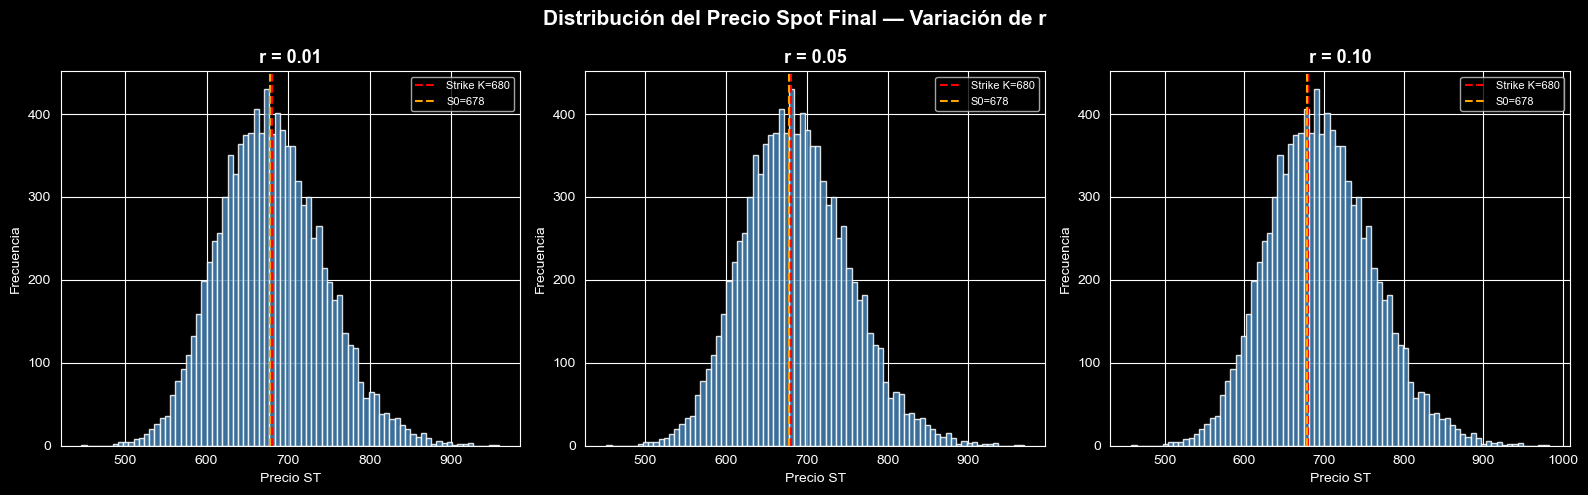

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (nombre, res) in enumerate(resultados_r.items()):
    ax = axes[i]
    ax.hist(res['St'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(K, color='red', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
    ax.axvline(float(S0), color='orange', linestyle='--', linewidth=1.5, label=f'S0={float(S0):.0f}')
    ax.set_title(f'{nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Precio ST')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

fig.suptitle('Distribución del Precio Spot Final — Variación de r', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
tabla_r = pd.DataFrame({
    'r': list(resultados_r.keys()),
    'Call Value (USD)': [f"{resultados_r[k]['call']:.4f}" for k in resultados_r],
    'Put Value (USD)':  [f"{resultados_r[k]['put']:.4f}"  for k in resultados_r]
})

print("Tabla — Valor de la Call por escenario de r")
print(tabla_r[['r', 'Call Value (USD)']].to_string(index=False))

print("\nTabla — Valor de la Put por escenario de r")
print(tabla_r[['r', 'Put Value (USD)']].to_string(index=False))

Tabla — Valor de la Call por escenario de r
       r Call Value (USD)
r = 0.01          25.1641
r = 0.05          28.8803
r = 0.10          33.9523

Tabla — Valor de la Put por escenario de r
       r Put Value (USD)
r = 0.01         25.4860
r = 0.05         21.8111
r = 0.10         17.7574


## Respuestas — Actividad 4: Tasa libre de riesgo

**¿Cómo cambia el crecimiento esperado del precio del activo?**

Al aumentar r, la distribución del precio final se desplaza ligeramente
hacia la derecha, lo que indica que el precio esperado del activo al
vencimiento es mayor. Esto se puede ver en las gráficas: con r = 0.01
la distribución está más centrada cerca de S0, mientras que con r = 0.10
hay una mayor masa de probabilidad en precios más altos. Esto es directo
del modelo GBM, donde r es la tasa de crecimiento esperado del activo.

**¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?**

La call aumenta conforme sube r: pasa de 25.59 USD con r = 0.01 a
34.43 USD con r = 0.10. Esto ocurre porque una tasa más alta implica
un precio futuro esperado más alto, lo que incrementa la probabilidad
de que el activo termine por encima del strike al vencimiento.

**¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?**

La put disminuye conforme sube r: pasa de 25.30 USD con r = 0.01 a
17.62 USD con r = 0.10. El razonamiento es el contrario al de la call:
un precio futuro esperado más alto reduce la probabilidad de que el activo
termine por debajo del strike, haciendo que la put valga menos.